In [13]:
from langgraph.graph import StateGraph, START, END
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter



In [6]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [7]:
loader = CSVLoader(file_path="../data/laws_de.csv")
laws_de = text_splitter.split_documents(loader.load())

loader = CSVLoader(file_path="../data/court_considerations.csv")
court_considerations = text_splitter.split_documents(loader.load())

In [10]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()
embeddings = OpenAIEmbeddings(
    model = "text-embedding-3-large"
)

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"}
)



In [17]:
vectorstore = FAISS.load_local(
    "faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)

RuntimeError: Error in faiss::FileIOReader::FileIOReader(const char *) at /Users/runner/work/faiss-wheels/faiss-wheels/third-party/faiss/faiss/impl/io.cpp:70: Error: 'f' failed: could not open faiss_index/index.faiss for reading: No such file or directory

In [27]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5} # k is the amount of chunks to return
)

In [18]:
from langchain_core.tools import tool
@tool
def retriever_tool(query: str) -> str:
    """
    this tool can search for laws citations and court considerations citations.
    """
    docs = retriever.invoke(query)

    if not docs:
        return "No relevant citation found"
    
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Docuemnt {i+1}:\n{doc.page_content}")

    return "\n\n".join(results)

In [36]:
import json
import re
import requests
import uuid
from typing import Any, List, Optional, Sequence, Union, Callable

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_core.utils.function_calling import convert_to_openai_tool

# =============================================================================
# SYSTEM PROMPT
# Injected automatically at the start of every conversation.
# Key rules embedded:
#   1. Always query the vector DB in German
#   2. Query multiple times with different German keywords until satisfied
#   3. Output ONLY a Python list of correctly formatted Swiss citations
# =============================================================================
SWISS_LAW_SYSTEM_PROMPT = """\
You are a Swiss legal citation expert. Your sole job is to find and return \
the most relevant Swiss legal citations for any query.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SEARCH RULES (follow strictly)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. ALWAYS search the vector database in GERMAN only.
   Translate every query into German legal terminology before searching.
2. You MUST perform multiple searches using different German keywords and
   synonyms until you are confident you have found all relevant citations.
   Typical keyword strategies:
     - Search by legal concept (e.g. "Vertragsabschluss", "Willensmangel")
     - Search by statute name   (e.g. "Obligationenrecht", "Zivilgesetzbuch")
     - Search by article number if known (e.g. "Art. 1 OR", "§ 12 StGB")
   Do NOT stop after just one search. Keep searching until you have explored
   all relevant angles of the legal question.
3. Collect citations from ALL your searches, then deduplicate.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CITATION FORMATS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Federal laws  → "Art. X ABBREV"   e.g. "Art. 1 OR", "Art. 8 ZGB"
  Common abbreviations: ZGB, OR, StGB, BV, SchKG, IPRG, ZPO, BGG, MSchG
Court decisions → "BGE X Y Z" or "BGE X Y Z E. N"
  e.g. "BGE 127 III 248 E. 3.1", "BGE 119 II 449 E. 2"

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OUTPUT FORMAT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
When you are satisfied with your research, output ONLY a Python list:
["citation1", "citation2", ...]

No explanations. No preamble. No markdown. ONLY the Python list.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXAMPLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Query: What are the requirements for a valid contract under Swiss law?
["Art. 1 OR", "Art. 11 OR", "Art. 12 OR", "BGE 119 II 449 E. 2", "BGE 127 III 248 E. 3.1"]

Query: When can a marriage be annulled in Switzerland?
["Art. 104 ZGB", "Art. 105 ZGB", "Art. 106 ZGB", "BGE 121 III 38 E. 2b"]

Query: What constitutes negligent homicide under Swiss criminal law?
["Art. 117 StGB", "Art. 12 StGB", "BGE 116 IV 306 E. 1a"]

Query: What are the grounds for divorce in Swiss law?
["Art. 111 ZGB", "Art. 112 ZGB", "Art. 114 ZGB", "Art. 115 ZGB", "BGE 130 III 585 E. 2.1"]

Query: How is inheritance distributed under Swiss law?
["Art. 457 ZGB", "Art. 462 ZGB", "Art. 471 ZGB", "BGE 132 III 305 E. 3.2"]
"""


class ModalMistralChat(BaseChatModel):
    """
    LangChain-compatible wrapper around a self-hosted Mistral REST endpoint.
    - bind_tools()  : serialises tools as JSON schemas injected into the prompt
    - _generate()   : parses tool-call JSON blocks → AIMessage.tool_calls
    - System prompt : auto-injected on every call if no SystemMessage present
    """

    api_url: str
    temperature: float = 0.1
    max_tokens: int = 1024
    system_prompt: str = SWISS_LAW_SYSTEM_PROMPT
    bound_tools: List[dict] = []

    @property
    def _llm_type(self) -> str:
        return "modal_mistral_chat"

    # ------------------------------------------------------------------
    # Tool binding
    # ------------------------------------------------------------------
    def bind_tools(
        self,
        tools: Sequence[Union[dict, type, Callable, BaseTool]],
        **kwargs: Any,
    ) -> "ModalMistralChat":
        tool_schemas = [convert_to_openai_tool(t)["function"] for t in tools]
        return self.model_copy(update={"bound_tools": tool_schemas})

    # ------------------------------------------------------------------
    # Prompt construction
    # ------------------------------------------------------------------
    def _build_tool_block(self) -> str:
        """Appended to the system prompt when tools are bound."""
        if not self.bound_tools:
            return ""
        schema_str = json.dumps(self.bound_tools, indent=2)
        return (
            "\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
            "AVAILABLE TOOLS\n"
            "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n"
            f"{schema_str}\n\n"
            "To call a tool, output ONLY a JSON block (no other text) like:\n"
            '{"tool": "<tool_name>", "tool_input": {"query": "<German search term>"}}\n'
            "Remember: always pass German search terms to the tool."
        )

    def _convert_messages_to_prompt(self, messages: List[BaseMessage]) -> str:
        has_system = any(isinstance(m, SystemMessage) for m in messages)
        tool_block = self._build_tool_block()
        prompt = ""

        # Auto-inject system prompt if the caller didn't provide one
        if not has_system:
            prompt += f"[SYSTEM]\n{self.system_prompt}{tool_block}\n"
            tool_block = ""  # Already injected

        for msg in messages:
            if isinstance(msg, SystemMessage):
                prompt += f"[SYSTEM]\n{msg.content}{tool_block}\n"
                tool_block = ""
            elif isinstance(msg, HumanMessage):
                prompt += f"[USER]\n{msg.content}\n"
            elif isinstance(msg, AIMessage):
                # Include any tool call JSON the model previously emitted
                content = msg.content or ""
                if msg.tool_calls:
                    tc = msg.tool_calls[0]
                    content = json.dumps({"tool": tc["name"], "tool_input": tc["args"]})
                prompt += f"[ASSISTANT]\n{content}\n"
            elif isinstance(msg, ToolMessage):
                prompt += f"[TOOL_RESULT]\n{msg.content}\n"

        prompt += "[ASSISTANT]\n"
        return prompt

    # ------------------------------------------------------------------
    # Core generation + tool-call parsing
    # ------------------------------------------------------------------
    def _generate(
        self,
        messages: List[BaseMessage],
        stop: Optional[List[str]] = None,
        **kwargs: Any,
    ) -> ChatResult:
        prompt = self._convert_messages_to_prompt(messages)

        response = requests.post(
            self.api_url,
            json={
                "prompt": prompt,
                "temperature": self.temperature,
                "max_tokens": self.max_tokens,
            },
            timeout=300,
        )
        response.raise_for_status()
        text: str = response.json()["response"].strip()

        if stop:
            for s in stop:
                text = text.split(s)[0]

        # ---- Detect and parse tool call ----
        tool_calls = []
        json_match = re.search(r"\{[^{}]*\"tool\"[^{}]*\}", text, re.DOTALL)
        if json_match and self.bound_tools:
            try:
                parsed = json.loads(json_match.group())
                if "tool" in parsed and "tool_input" in parsed:
                    tool_calls = [
                        {
                            "name": parsed["tool"],
                            "args": parsed["tool_input"],
                            "id": f"call_{uuid.uuid4().hex[:8]}",
                            "type": "tool_call",
                        }
                    ]
                    text = text[: json_match.start()].strip()
            except (json.JSONDecodeError, KeyError):
                pass

        return ChatResult(
            generations=[
                ChatGeneration(message=AIMessage(content=text, tool_calls=tool_calls))
            ]
        )


In [37]:
llm = ModalMistralChat(
    api_url="https://keshavsharma25--mistral-7b-instruct-api-fastapi-app.modal.run/generate",
    temperature=0.1,
    max_tokens=512,
)


In [38]:
llm_with_tools = llm.bind_tools([retriever_tool])

# Sanity check — should print the tool schema, not raise NotImplementedError
print("Bound tools:", [t["name"] for t in llm_with_tools.bound_tools])


Bound tools: ['retriever_tool']


Graph compiled ✅
Agent will search minimum 3× and maximum 8× per query.



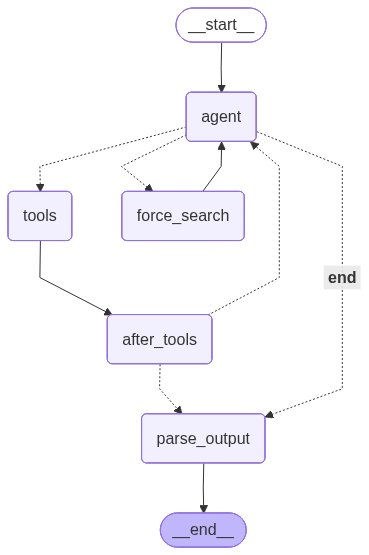

In [39]:
import ast
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# ── Tuning knobs ──────────────────────────────────────────────────────────────
MIN_TOOL_CALLS = 3   # Agent MUST search at least this many times before finishing
MAX_TOOL_CALLS = 8   # Hard ceiling to prevent infinite loops
# ─────────────────────────────────────────────────────────────────────────────


# =============================================================================
# Graph State
# =============================================================================
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    tool_call_count: int          # How many DB searches have been made so far
    final_citations: list[str]    # Parsed final citation list


# =============================================================================
# Node 1 — agent
# Calls the LLM. The system prompt (with search rules + output format) is
# automatically injected by ModalMistralChat._convert_messages_to_prompt().
# =============================================================================
def call_model(state: AgentState) -> AgentState:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# =============================================================================
# Node 2 — tools
# Standard LangGraph ToolNode — reads tool_calls from the last AIMessage,
# executes retriever_tool, and appends a ToolMessage with the results.
# =============================================================================
tool_node = ToolNode(tools=[retriever_tool])


# =============================================================================
# Node 3 — after_tools
# Runs after every tool execution. Increments the counter and, once MIN_TOOL_CALLS
# is reached, appends a follow-up prompt nudging the agent to either keep
# searching or produce its final citation list.
# =============================================================================
def after_tools(state: AgentState) -> AgentState:
    count = state.get("tool_call_count", 0) + 1
    updates: AgentState = {"tool_call_count": count, "messages": []}

    if count < MIN_TOOL_CALLS:
        # Encourage the agent to keep searching with different German keywords
        nudge = HumanMessage(
            content=(
                f"Good. You have searched {count} time(s). "
                f"You must search at least {MIN_TOOL_CALLS} times total. "
                "Search again using DIFFERENT German keywords or synonyms to find "
                "more citations you may have missed."
            )
        )
        updates["messages"] = [nudge]
    else:
        # Agent has met the minimum — invite it to conclude or keep going
        nudge = HumanMessage(
            content=(
                f"You have now searched {count} time(s). "
                "If you are satisfied with your research, output ONLY the final "
                "Python list of citations now. "
                "If you think important angles are still uncovered, search once more "
                "with a new German keyword, then output the list."
            )
        )
        updates["messages"] = [nudge]

    return updates


# =============================================================================
# Routing — decides what happens after the agent responds
# =============================================================================
def route_agent(state: AgentState) -> str:
    """
    After the agent node:
      • If the last message has tool_calls  → go to tools
      • If we're below MIN_TOOL_CALLS       → force another search via tools
      • Otherwise                           → end (agent produced final answer)
    """
    last_msg = state["messages"][-1]
    count = state.get("tool_call_count", 0)

    # Model wants to call a tool
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"

    # Model tried to finish too early — inject a nudge and loop back
    if count < MIN_TOOL_CALLS:
        # Append a forceful re-search instruction
        return "force_search"

    # Model is done — parse citations and end
    return END


def force_search(state: AgentState) -> AgentState:
    """
    Injected when the agent tries to finish before MIN_TOOL_CALLS.
    Overwrites the last message with a hard instruction to search again.
    """
    count = state.get("tool_call_count", 0)
    instruction = HumanMessage(
        content=(
            f"You have only searched {count} time(s) but must search at least "
            f"{MIN_TOOL_CALLS} times. Call the retriever_tool NOW with a NEW "
            "German keyword before giving your final answer."
        )
    )
    return {"messages": [instruction]}


# =============================================================================
# Node — parse_output
# Extracts the Python list from the agent's final text response and stores it
# in state["final_citations"] for easy downstream consumption.
# =============================================================================
def parse_output(state: AgentState) -> AgentState:
    last_msg = state["messages"][-1]
    text = last_msg.content if hasattr(last_msg, "content") else str(last_msg)

    citations = []
    # Try to find a Python list literal anywhere in the response
    list_match = re.search(r"\[.*?\]", text, re.DOTALL)
    if list_match:
        try:
            citations = ast.literal_eval(list_match.group())
        except (ValueError, SyntaxError):
            # Fallback: split on comma inside brackets
            inner = list_match.group().strip("[] ")
            citations = [c.strip().strip('"\'') for c in inner.split(",") if c.strip()]

    return {"final_citations": citations}


# =============================================================================
# Routing — after tools node
# Always goes to after_tools first (to increment counter + maybe nudge),
# then back to agent.
# =============================================================================
def route_after_tools(state: AgentState) -> str:
    count = state.get("tool_call_count", 0)
    if count >= MAX_TOOL_CALLS:
        return "parse_output"   # Hard ceiling reached — go straight to parse
    return "agent"


# =============================================================================
# Build the graph
# =============================================================================
graph = StateGraph(AgentState)

graph.add_node("agent",        call_model)
graph.add_node("tools",        tool_node)
graph.add_node("after_tools",  after_tools)
graph.add_node("force_search", force_search)
graph.add_node("parse_output", parse_output)

# Entry point
graph.add_edge(START, "agent")

# After agent: route to tools / force_search / END
graph.add_conditional_edges(
    "agent",
    route_agent,
    {"tools": "tools", "force_search": "force_search", END: "parse_output"},
)

# force_search always goes back to agent
graph.add_edge("force_search", "agent")

# tools → after_tools → (agent or parse_output based on MAX cap)
graph.add_edge("tools", "after_tools")
graph.add_conditional_edges(
    "after_tools",
    route_after_tools,
    {"agent": "agent", "parse_output": "parse_output"},
)

graph.add_edge("parse_output", END)

app = graph.compile()
print("Graph compiled ✅")
print(f"Agent will search minimum {MIN_TOOL_CALLS}× and maximum {MAX_TOOL_CALLS}× per query.\n")

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Nodes:", list(app.get_graph().nodes.keys()))


In [ ]:
# =============================================================================
# Run the agent on a sample query
# =============================================================================
def run_query(question: str, verbose: bool = True) -> list[str]:
    """
    Runs the full agentic retrieval pipeline for a single question.
    Returns a deduplicated list of Swiss legal citations.
    """
    initial_state: AgentState = {
        "messages": [HumanMessage(content=question)],
        "tool_call_count": 0,
        "final_citations": [],
    }

    final_state = app.invoke(
        initial_state,
        config={"recursion_limit": 50},   # safety ceiling for graph recursion
    )

    citations = final_state.get("final_citations", [])

    if verbose:
        searches = final_state.get("tool_call_count", 0)
        print(f"Question : {question}")
        print(f"Searches : {searches}")
        print(f"Citations ({len(citations)}):")
        for c in citations:
            print(f"  • {c}")

    return citations


# ── Example ──────────────────────────────────────────────────────────────────
citations = run_query("What are the requirements for a valid contract under Swiss law?")
